In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet,ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
from sklearn.linear_model import RidgeCV
np.random.seed(42)

In [ ]:
df = pd.read_csv("Housing.csv")

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
print(df.isna().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
df.info()
X= df.drop("price", axis=1)
y= df["price"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
num_columns= ['area','bedrooms','bathrooms','stories','parking']
cat_columns= ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']

In [ ]:
preprocessor= ColumnTransformer([
    ("num", StandardScaler(), num_columns),
    ("cat", OneHotEncoder(drop='first'), cat_columns)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu  :", X_test.shape)


Eğitim seti boyutu: (436, 12)
Test seti boyutu  : (109, 12)


In [ ]:
alphas = np.logspace(-4, 4, 100)

In [ ]:
ridge_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('Ridge', Ridge(alpha=1))])

In [ ]:
ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred))
print("Ridge MSE:", mean_squared_error(y_test, y_pred))
print("Ridge MAE:", mean_absolute_error(y_test, y_pred))

Ridge R2: 0.6520909242049431
Ridge MSE: 1758530862952.2085
Ridge MAE: 971370.2374030846


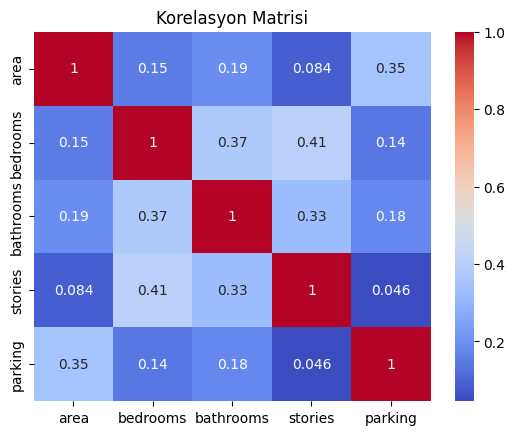

In [ ]:
corr_matrix =df[num_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Korelasyon Matrisi')
plt.show()

In [ ]:
alphas = np.logspace(-3, 3, 10)

In [ ]:
ridge_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('Ridge', RidgeCV(alphas=alphas,cv=5))])

In [ ]:
ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)
ridge_mse=mean_squared_error(y_test, y_pred)
ridge_mae=mean_absolute_error(y_test, y_pred)
ridge_r2 = r2_score(y_test, y_pred)

print("Ridge R2:", r2_score(y_test, y_pred))
print("Ridge MSE:", mean_squared_error(y_test, y_pred))
print("Ridge MAE:", mean_absolute_error(y_test, y_pred))

best_alpha = ridge_pipeline.named_steps['Ridge'].alpha_
print("Best alpha:", best_alpha)

Ridge R2: 0.6454739045516407
Ridge MSE: 1791977053611.3684
Ridge MAE: 979663.5036785456
Best alpha: 10.0


Lasso Regresyon (L1 Regularizasyon)

In [ ]:
lasso_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('Lasso', Lasso(alpha=1))])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
print(f"Lasso -> MSE: {lasso_mse:.2f} | MAE: {lasso_mae:.2f}")
lasso_r2 = r2_score(y_test, y_pred_lasso)
print(f"Lasso -> R2: {lasso_r2:.4f}")

Lasso -> MSE: 1754321781091.54 | MAE: 970044.03
Lasso -> R2: 0.6529


In [ ]:
from sklearn.linear_model import LassoCV
lassocv_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('Lasso', LassoCV(alphas=alphas,cv=5))])

In [ ]:
lassocv_pipeline.fit(X_train, y_train)
best_alpha_lasso=lassocv_pipeline.named_steps['Lasso'].alpha_

In [ ]:
print("Best alpha:", best_alpha_lasso)

Best alpha: 0.001


Elastic Net Regresyon (L1 + L2 Kombinasyonu)

In [ ]:
elasticnet_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('ElasticNet', ElasticNet(alpha=1, l1_ratio=0.5,max_iter=1000))])

In [ ]:
elasticnet_pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('ElasticNet', ElasticNet(alpha=1))])

In [ ]:
y_pred_elasticnet = elasticnet_pipeline.predict(X_test)

elastic_mse = mean_squared_error(y_test, y_pred_elasticnet)
elastic_mae = mean_absolute_error(y_test, y_pred_elasticnet)
print(f"ElasticNet -> MSE: {elastic_mse:.2f} | MAE: {elastic_mae:.2f}")
elastic_r2 = r2_score(y_test, y_pred_elasticnet)
print(f"ElasticNet -> R2: {elastic_r2:.4f}")

ElasticNet -> MSE: 2274309868242.29 | MAE: 1110583.14
ElasticNet -> R2: 0.5500


In [ ]:
sonuclar = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "ElasticNet"],
    "MSE": [ridge_mse, lasso_mse, elastic_mse],
    "MAE": [ridge_mae, lasso_mae, elastic_mae],
    "R2": [ridge_r2, lasso_r2, elastic_r2]
})

sonuclar = sonuclar.sort_values("R2", ascending=False)
sonuclar

,Model,MSE,MAE,R2
1,Lasso,1.754322e+12,9.700440e+05,0.652924
0,Ridge,1.791977e+12,9.796635e+05,0.645474
2,ElasticNet,2.274310e+12,1.110583e+06,0.550049


In [ ]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished
